In [5]:
from sympleq.core.symmetries import pauli_reduce, min_qudit_clifford_symmetry, qudit_cost
from sympleq.models.Ising import ising_chain_hamiltonian, ising_2d_hamiltonian, heuristic_clifford_symmetry
from sympleq.core.circuits.gate_decomposition_to_circuit import gate_to_circuit
import numpy as np
import time

In [2]:

N = 5
J = 1
h = 0.5
periodic = False
H = ising_chain_hamiltonian(N, J, h, periodic=periodic)

# print(H)

# h_red, conditioned_hamiltonians, C_F, all_phases = pauli_reduce(H)
# print(h_red)
# print(conditioned_hamiltonians)


In [3]:
H_c = H  #conditioned_hamiltonians[0]
F, S, T = min_qudit_clifford_symmetry(H_c, check_symmetry=True)

print(F.symplectic)
print(heuristic_clifford_symmetry(N, periodic).symplectic)

# print(heuristic_clifford_symmetry(N))
# assert np.all(F.symplectic == heuristic_clifford_symmetry(N, periodic).symplectic)

assert F == heuristic_clifford_symmetry(N, periodic)
C_F = gate_to_circuit(F)
# C_S = gate_to_circuit(S)
# C_T = gate_to_circuit(T)
assert C_F.act(H_c).to_standard_form() == H_c.to_standard_form()
# assert C_S.act(C_T.act(H_c)).standard_form() == H_c.standard_form()
U_F = C_F.unitary().toarray()
H_hilbert = H_c.to_hilbert_space().toarray()
assert np.all(np.abs(U_F @ H_hilbert @ U_F.conj().T - H_hilbert) < 1e-8)
print('Found unitary symmetry!!!')

[[0 0 0 0 1 1 1 1 1 1]
 [0 0 0 1 0 1 1 1 1 1]
 [0 0 1 0 0 1 1 1 1 1]
 [0 1 0 0 0 1 1 1 1 1]
 [1 0 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]
[[0 0 0 0 1 1 1 1 1 1]
 [0 0 0 1 0 1 1 1 1 1]
 [0 0 1 0 0 1 1 1 1 1]
 [0 1 0 0 0 1 1 1 1 1]
 [1 0 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]
Found unitary symmetry!!!


In [ ]:
# print(S.symplectic)
# assert T.inv().act(S.act(T.act(H_c))).standard_form() == H_c.standard_form()
# print(H_c.n_qudits())
print(qudit_cost(F))
print(qudit_cost(S))

4
4
2


In [ ]:
# timing 1d Ising
Ns = [8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
J = 1
h = 0.5
periodic = False

times = []
for N in Ns:
    H = ising_chain_hamiltonian(N, J, h, periodic=periodic)
    start = time.time()
    F, T, S = min_qudit_clifford_symmetry(H, check_symmetry=True)
    end = time.time()
    times.append(end - start)
    print(f"N={N}, time={end - start}")

N=8, time=0.1834409236907959
N=10, time=0.25961947441101074
N=12, time=0.3544764518737793
N=14, time=0.4780704975128174
N=16, time=0.6285946369171143
N=18, time=0.9783401489257812
N=20, time=8.628655910491943
N=22, time=872.6052534580231


Text(0, 0.5, 'Time (s)')

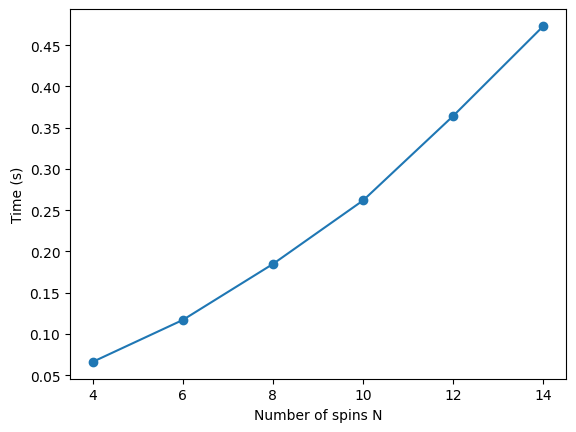

In [7]:
# plot times
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(Ns, times, marker='o')
ax.set_xlabel('Number of spins N')
ax.set_ylabel('Time (s)')

In [ ]:
n_x = 3
n_y = 2
J_zz = 1
h_x = 0.5
H_2d = ising_2d_hamiltonian(n_x, n_y, J_zz, h_x, periodic=False)

h_red, conditioned_hamiltonians, C_F, all_phases = pauli_reduce(H_2d)
print(conditioned_hamiltonians[0].n_qudits())
print(conditioned_hamiltonians[0].n_paulis())